## Decision Tree Regression


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['Price'] = housing.target

# Print first 5 rows
print("First 5 rows:")
print(df.head())

# Print last 5 rows
print("\nLast 5 rows:")
print(df.tail())

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Last 5 rows:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123

In [6]:
# Shape of dataset
print("Shape of Dataset:", df.shape)

# Information
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (20640, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


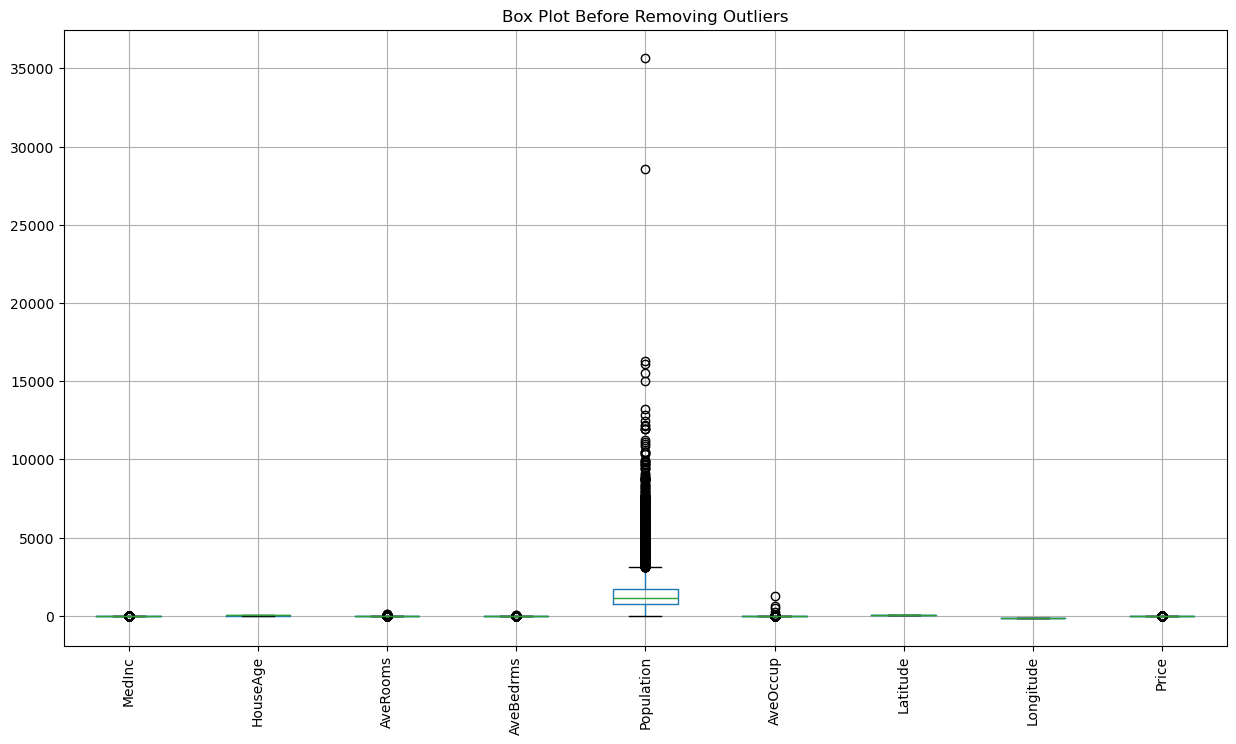

In [7]:
plt.figure(figsize=(15,8))
df.boxplot()
plt.xticks(rotation=90)
plt.title("Box Plot Before Removing Outliers")
plt.show()

In [8]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

# Remove outliers
df_filtered = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_filtered.shape)

Original Shape: (20640, 9)
Shape After Removing Outliers: (16312, 9)


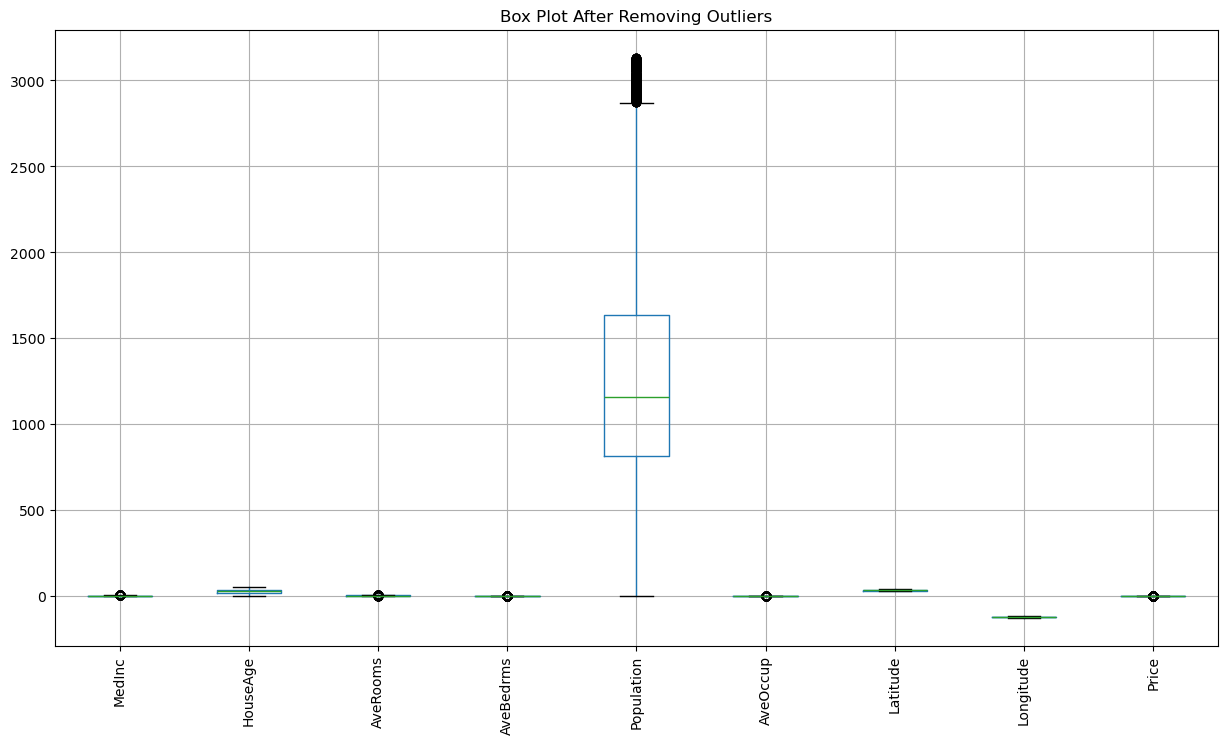

In [9]:
plt.figure(figsize=(15,8))
df_filtered.boxplot()
plt.xticks(rotation=90)
plt.title("Box Plot After Removing Outliers")
plt.show()

In [10]:
# Features (X)
X = df_filtered.drop('Price', axis=1)

# Target (y)
y = df_filtered['Price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (16312, 8)
Target Shape: (16312,)


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13049, 8)
X_test shape: (3263, 8)
y_train shape: (13049,)
y_test shape: (3263,)


In [14]:
model = DecisionTreeRegressor(random_state=42)

model.fit(X_train, y_train)

print("Decision Tree Regression Model Trained Successfully")
model

Decision Tree Regression Model Trained Successfully


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[2.113 1.266 2.138 3.639 1.826 0.67  3.36  0.539 1.431 2.167]


In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.4313726631933803
Mean Squared Error (MSE): 0.41483570793748076
Root Mean Squared Error (RMSE): 0.6440774083427245
R2 Score: 0.5254252272489047


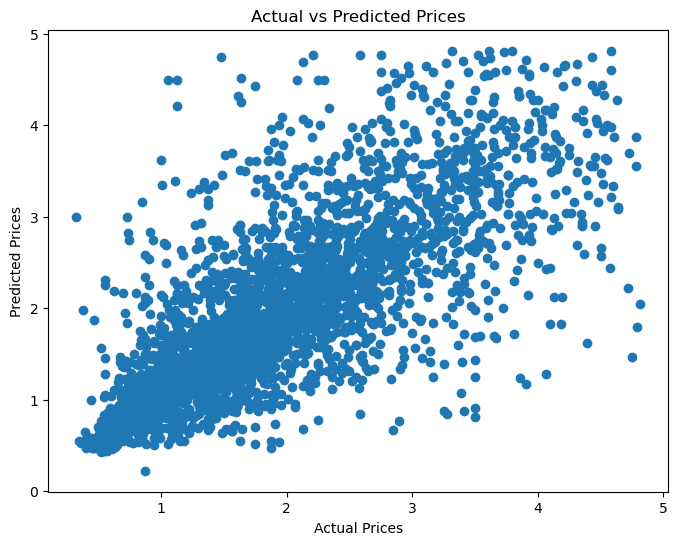

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

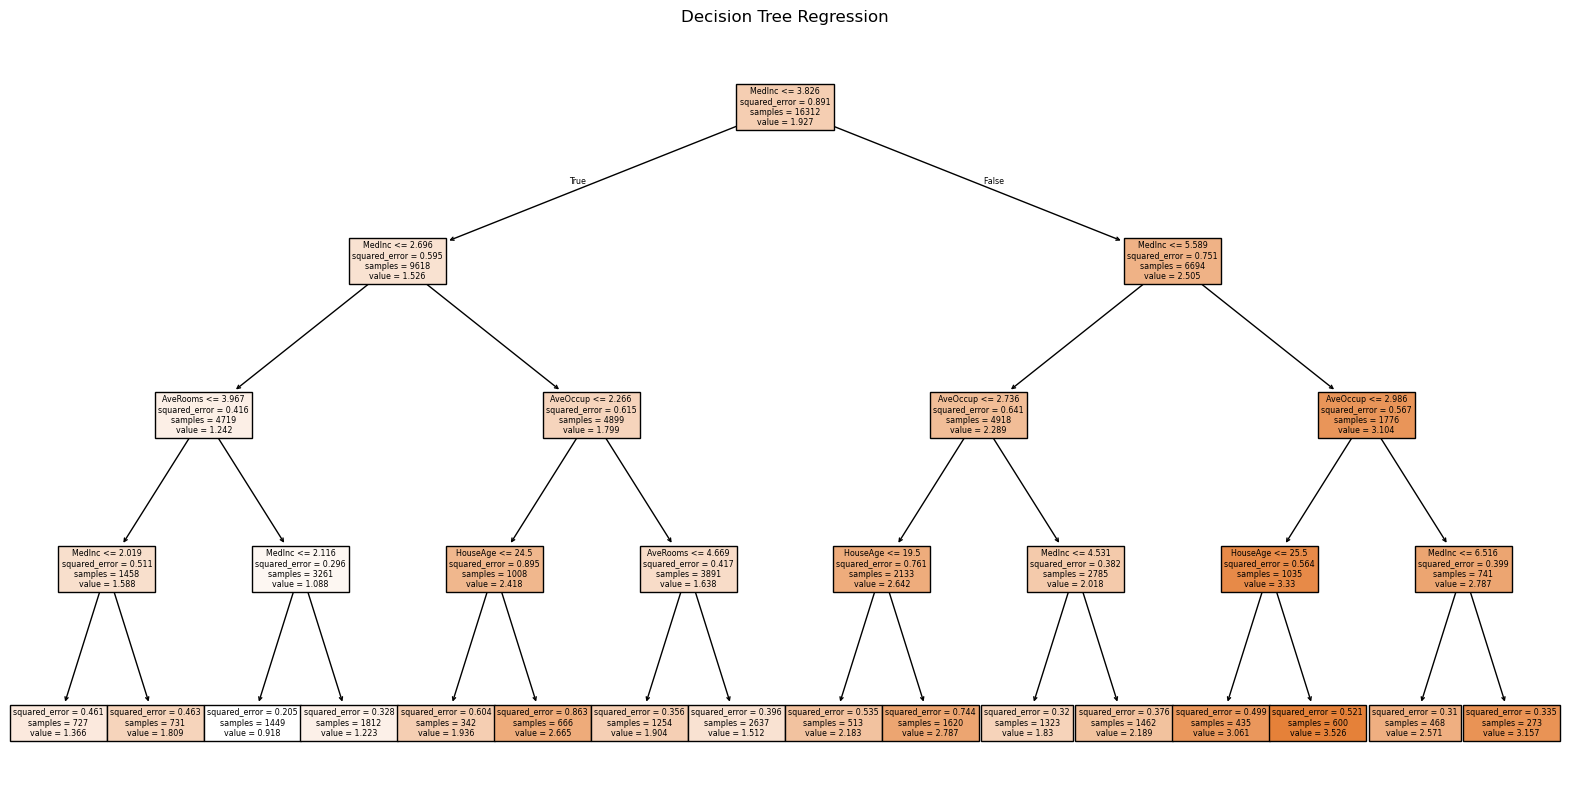

In [19]:
# 1. Re-define the model with a max depth limit
model = DecisionTreeRegressor(max_depth=4, random_state=42)

# 2. Re-fit the model
model.fit(X, y)

# 3. Your plotting code will now run instantly
plt.figure(figsize=(20,10))
plot_tree(
    model,
    filled=True,
    feature_names=X.columns
)
plt.title("Decision Tree Regression")
plt.show()

In [20]:
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV

In [21]:
model = DecisionTreeRegressor(random_state=42)

print("Model Parameters:")
print(model.get_params())

Model Parameters:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [22]:
param_grid = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(param_grid)

{'max_depth': [3, 5, 10, 15], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


In [25]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid Search Completed")
grid_search

Grid Search Completed


,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [24]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best Score:
0.6498743078278831


In [26]:
y_pred = grid_search.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[2.4163913  1.18880992 2.15310044 3.24675362 2.6393     1.09565714
 3.24675362 0.5704321  1.32881818 0.93204018]


In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 0.3775338489450792
Mean Squared Error: 0.29086096320118204
Root Mean Squared Error: 0.5393152725458292
R2 Score: 0.6672531489642913


In [28]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual  Predicted
0   2.594   2.416391
1   1.164   1.188810
2   2.084   2.153100
3   4.537   3.246754
4   2.697   2.639300
5   1.144   1.095657
6   3.500   3.246754
7   0.558   0.570432
8   1.844   1.328818
9   0.797   0.932040


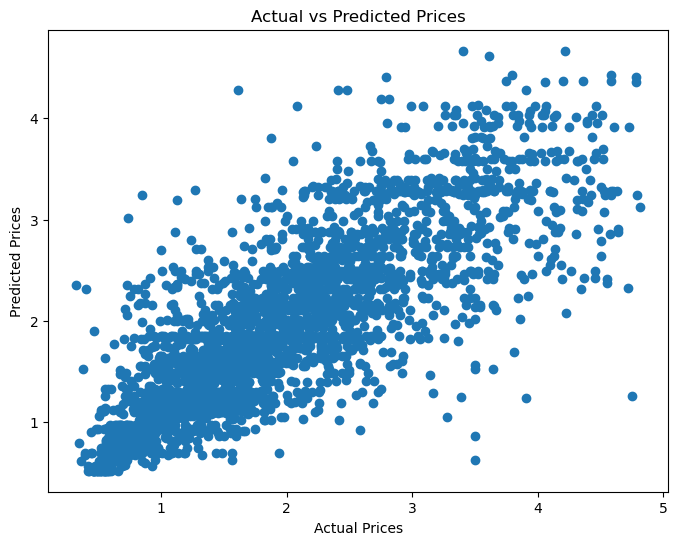

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

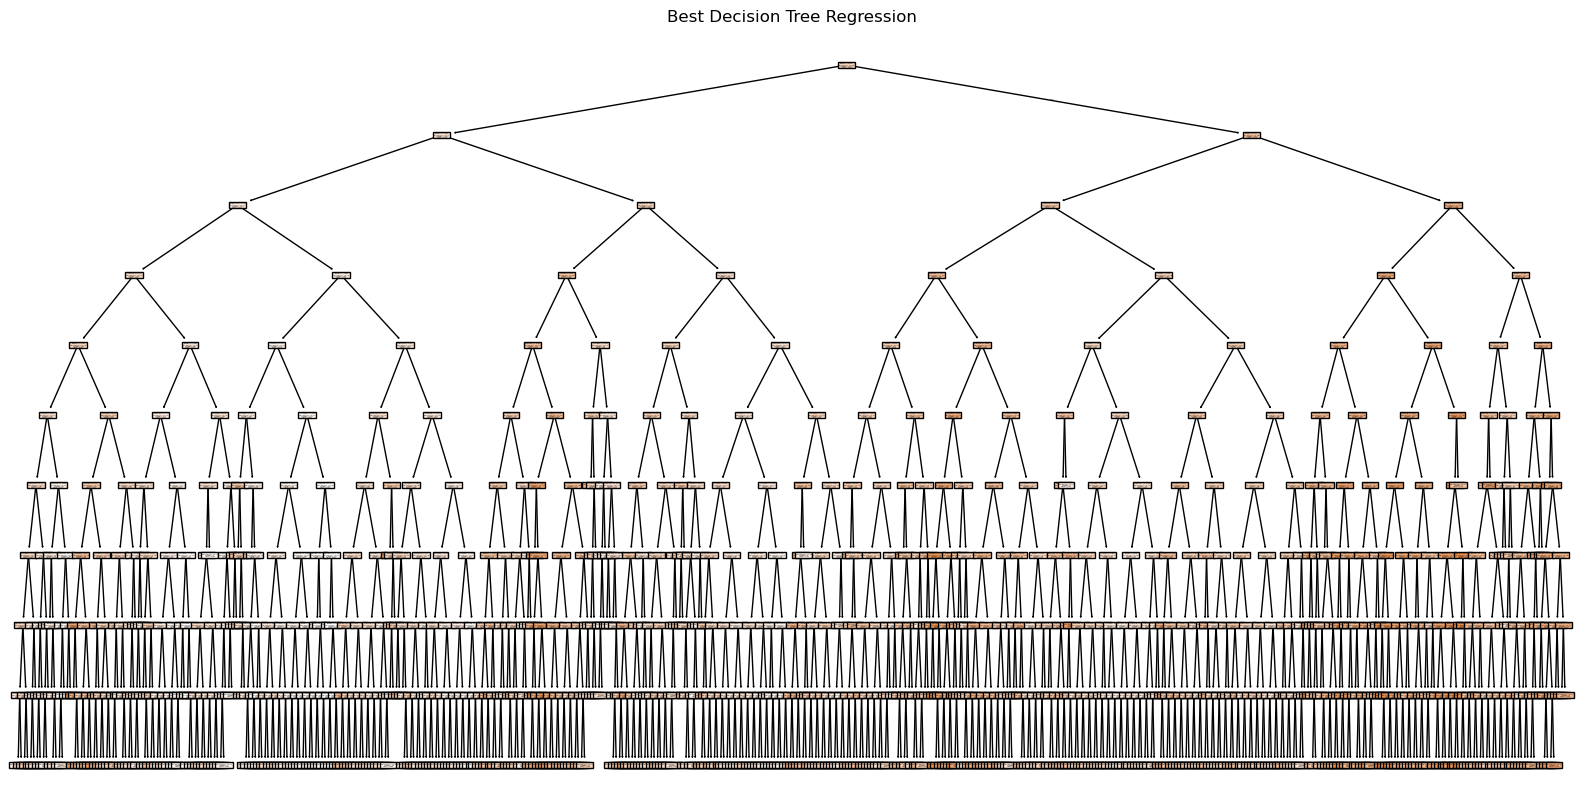

In [30]:
best_model = grid_search.best_estimator_

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    filled=True,
    feature_names=X.columns
)

plt.title("Best Decision Tree Regression")

plt.show()